# Exploratory Data Analysis
In this notebook I:
1. Inspect, clean, and explore the global_tech_startups_2026 dataset by reviewing its structure, data types, null values, and duplicate values.
2. Perform descriptive statistics, analyze the distribution of key variables, and compare the selected performance variables across AI adoption levels.
3. Recognize early relationships between AI adoption and the performance variables.

## Loading libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the dataset

In [2]:
data = pd.read_csv("global_tech_startups_2026.csv")
data.head()

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


## Describing the data

In [3]:
data.shape

(25000, 17)

In [4]:
data.columns

Index(['Company_ID', 'Domain', 'Founding_Year', 'Country', 'City',
       'Funding_Stage', 'Total_Funding_USD_Millions', 'Valuation_USD_Millions',
       'Revenue_ARR_Millions', 'Monthly_Burn_Rate_Millions',
       'Runway_Months_2024', 'Peak_Headcount_2023', 'Layoffs_2024_2025',
       'Current_Headcount_2026', 'Investor_Tier', 'AI_Adoption_Level',
       'Acquisition_Status'],
      dtype='str')

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company_ID                  25000 non-null  str    
 1   Domain                      25000 non-null  str    
 2   Founding_Year               25000 non-null  int64  
 3   Country                     25000 non-null  str    
 4   City                        25000 non-null  str    
 5   Funding_Stage               25000 non-null  str    
 6   Total_Funding_USD_Millions  25000 non-null  float64
 7   Valuation_USD_Millions      25000 non-null  float64
 8   Revenue_ARR_Millions        25000 non-null  float64
 9   Monthly_Burn_Rate_Millions  25000 non-null  float64
 10  Runway_Months_2024          25000 non-null  float64
 11  Peak_Headcount_2023         25000 non-null  int64  
 12  Layoffs_2024_2025           25000 non-null  int64  
 13  Current_Headcount_2026      25000 non-null

## Identifying null values

In [6]:
data.isna().sum()

Company_ID                       0
Domain                           0
Founding_Year                    0
Country                          0
City                             0
Funding_Stage                    0
Total_Funding_USD_Millions       0
Valuation_USD_Millions           0
Revenue_ARR_Millions             0
Monthly_Burn_Rate_Millions       0
Runway_Months_2024               0
Peak_Headcount_2023              0
Layoffs_2024_2025                0
Current_Headcount_2026           0
Investor_Tier                    0
AI_Adoption_Level             2592
Acquisition_Status               0
dtype: int64

There are only null values in the AI_Adoption_Level column.

Because of the large amount of null values, I will replace them with 'No AI Adoption'.

It will be **assumed** that the NaN values mean that there is no AI adoption.

In [7]:
data = data.fillna('No AI Adoption')
data.head()

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),No AI Adoption,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


In [8]:
# To verify that the changes were made as expected.
data.isna().sum()

Company_ID                    0
Domain                        0
Founding_Year                 0
Country                       0
City                          0
Funding_Stage                 0
Total_Funding_USD_Millions    0
Valuation_USD_Millions        0
Revenue_ARR_Millions          0
Monthly_Burn_Rate_Millions    0
Runway_Months_2024            0
Peak_Headcount_2023           0
Layoffs_2024_2025             0
Current_Headcount_2026        0
Investor_Tier                 0
AI_Adoption_Level             0
Acquisition_Status            0
dtype: int64

There are no null values.

## Identifying duplicate values

In [9]:
data.duplicated().sum()

np.int64(0)

There are no duplicate values.

## Descriptive Statistics

In [10]:
data.describe()

,Founding_Year,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,2018.917400,59.631098,464.100121,33.300890,3.168847,12.189032,211.739920,31.563320,180.176600
std,2.811963,208.725699,1777.909318,139.243809,10.877553,10.099990,693.946443,175.987811,606.174385
min,2012.000000,0.000000,1.030000,0.050000,0.060000,0.000000,5.000000,0.000000,0.000000
25%,2017.000000,2.050000,28.997500,1.800000,0.430000,3.900000,30.000000,0.000000,22.000000
50%,2019.000000,8.465000,71.775000,4.825000,0.720000,10.600000,48.000000,0.000000,42.000000
75%,2021.000000,36.100000,267.795000,17.972500,2.240000,17.500000,154.000000,16.000000,119.000000
max,2025.000000,7867.390000,91692.420000,9021.530000,515.760000,89.600000,30086.000000,10280.000000,25657.000000


Since the mean is not resistant to extreme values, when the mean is greater than the median, the distribution of a variable tends to be right-skewed.

The means of *Total_Funding_USD_Millions*, *Valuation_USD_Millions*, *Revenue_ARR_Millions*, *Peak_Headcount_2023*, *Layoffs_2024_2025*, and *Current_Headcount_2026* are considerably higher than their medians (50th percentiles), so, it can be interpreted that their distributions are right-skewed.

To verify visually that their distribution is right-skewed, I will generate a histogram for each variable.

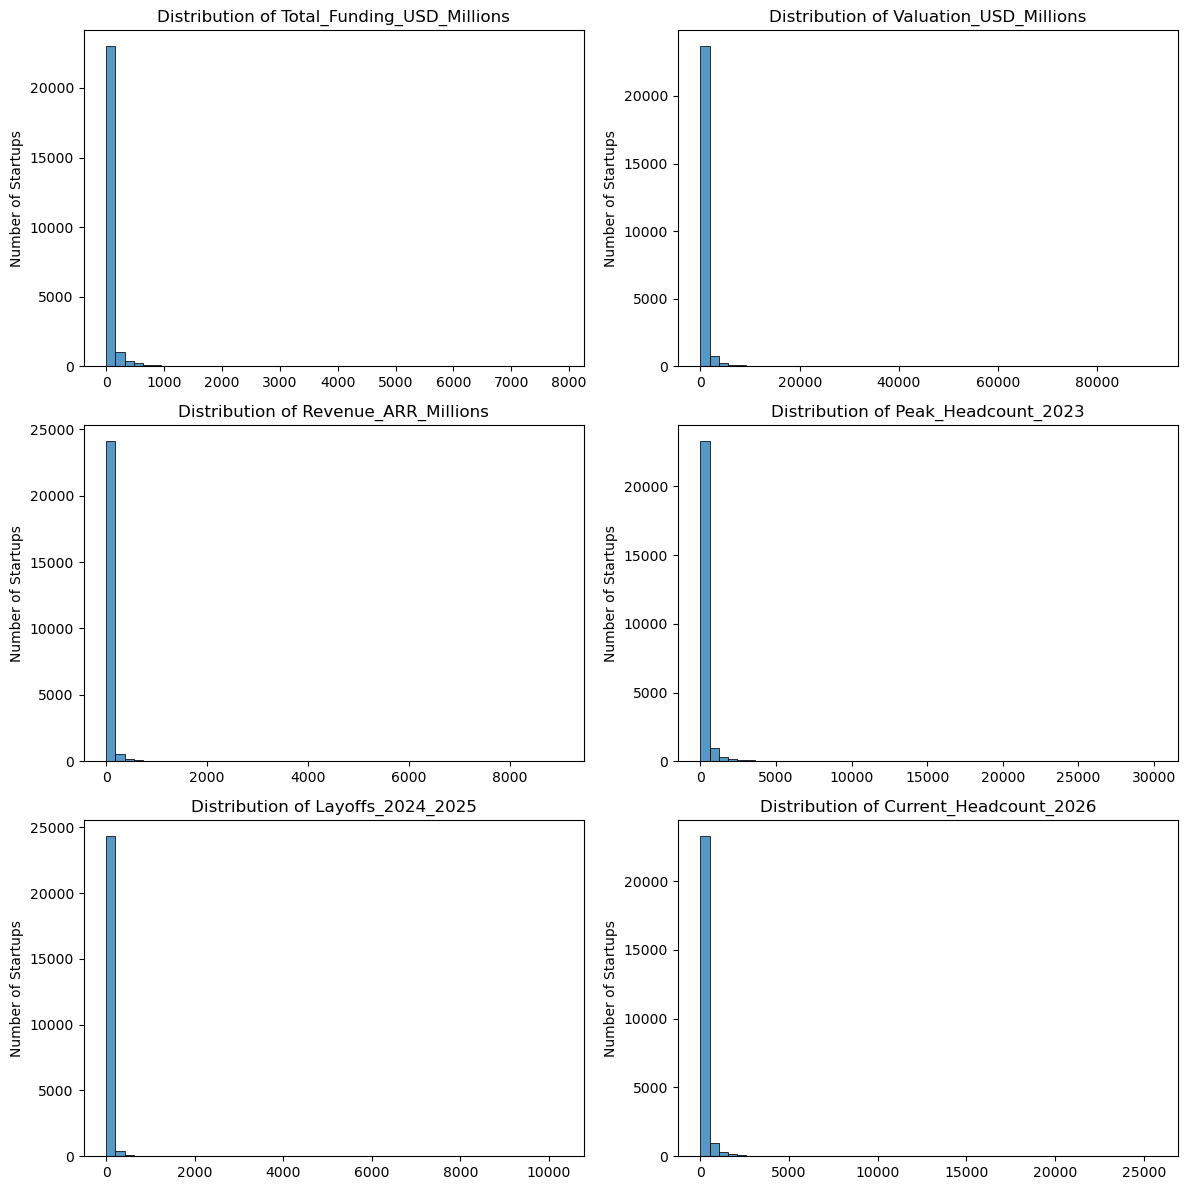

In [11]:
# List of variables that show right skewness
variables_skewed = [
    'Total_Funding_USD_Millions',
    'Valuation_USD_Millions',
    'Revenue_ARR_Millions',
    'Peak_Headcount_2023',
    'Layoffs_2024_2025',
    'Current_Headcount_2026'
]

# To create a 3x2 grid for subplots
fig, axes = plt.subplots(3, 2, figsize = (12, 12))

# To iterate for each variable
for i, variable in enumerate(variables_skewed):
    sns.histplot(data[variable], bins = 50, ax = axes.flat[i])
    axes.flat[i].set_title(f'Distribution of {variable}')
    axes.flat[i].set_ylabel('Number of Startups')
    axes.flat[i].set_xlabel('') 

plt.tight_layout()
plt.show()

The histograms confirm that these variables have right-skewed distributions.

**For the remainder of the analysis, I will focus on the variables *Revenue_ARR_Millions*, *Valuation_USD_Millions*, *Total_Funding_USD_Millions*, *Layoffs_2024_2025*, *Current_Headcount_2026*, and *Runway_Months_2024*, since they directly address the objectives established in the README.**

**Although Peak_Headcount_2023 showed a right-skewed distribution, I excluded it from the main analysis because Current_Headcount_2026 provides a current measure of the same operational metric.**

**Variables like *Founding_Year* and *Monthly_Burn_Rate_Millions* are not relevant to the objectives, so they will not be analyzed.**

The next step is to group the variables by their AI adoption level, in order to compare their means and medians.

In [12]:
# List of the key variables
performance_variables = [
    'Revenue_ARR_Millions',
    'Valuation_USD_Millions',
    'Total_Funding_USD_Millions',
    'Layoffs_2024_2025',
    'Current_Headcount_2026',
    'Runway_Months_2024'
]

In [13]:
data.groupby('AI_Adoption_Level')[performance_variables].median()

,Revenue_ARR_Millions,Valuation_USD_Millions,Total_Funding_USD_Millions,Layoffs_2024_2025,Current_Headcount_2026,Runway_Months_2024
AI_Adoption_Level,,,,,,
High,4.910,71.955,8.420,0.0,42.0,10.6
Low,4.990,76.205,9.100,0.0,43.0,11.1
Medium,4.570,68.335,8.035,0.0,42.0,10.4
No AI Adoption,4.955,73.695,8.460,0.0,43.0,10.7


In [14]:
data.groupby('AI_Adoption_Level')[performance_variables].mean()

,Revenue_ARR_Millions,Valuation_USD_Millions,Total_Funding_USD_Millions,Layoffs_2024_2025,Current_Headcount_2026,Runway_Months_2024
AI_Adoption_Level,,,,,,
High,32.687201,457.276563,58.528715,31.371918,175.960057,12.238975
Low,31.357247,439.948959,56.953327,31.214089,173.544274,12.300945
Medium,35.256144,502.093224,63.988733,33.764377,193.329207,12.033946
No AI Adoption,33.768669,427.178214,56.426111,26.593750,171.027006,12.229977


A Low AI adoption level is associated with a higher median for all the variables analyzed, while a Medium AI adoption level is associated with a higher mean for almost all variables analyzed.

The descriptive analysis suggests that a high AI adoption level does not necessarily impact the performance of global tech and AI startups.

## Exporting the dataset

In [15]:
data.to_csv("global_tech_startups_cleaned.csv", index = False)

In the next Jupyter Notebook the association between AI adoption level and the performance variables will be tested using one-way ANOVA.